In [1]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph,START,END

In [2]:
class AgentState(TypedDict):
    number01 : int
    number02 : int
    operation : str
    final_value : int


In [3]:
def addition(state: AgentState) -> AgentState:
    state['final_value'] = state["number01"] + state["number02"]
    return state

def subtraction(state: AgentState) -> AgentState:
    state['final_value'] = state["number01"] - state["number02"]
    return state

# def condition(state: AgentState)-> AgentState:
#    if state[operation] == "+" :
#        return "addition"
#    elif state[operation] == "-" :
#        return "subtraction"

def decide_next_node(state: AgentState) -> str:
    op = state.get("operation")
    if op == "+":
        return "addition"
    if op == "-":
        return "subtraction"
    raise ValueError(f"unknown operation: {op!r}")

In [4]:
graph = StateGraph(AgentState)

graph.add_node("add", addition)
graph.add_node("sub", subtraction)
graph.add_node("router", lambda state:state)

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "addition" : "add",
        "subtraction" : "sub"
    }

)


graph.add_edge("add", END)
graph.add_edge("sub" , END)

app = graph.compile()

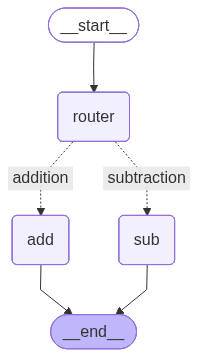

In [5]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
result = app.invoke({
    "number01" : 1,
    "number02" : 2,
    "operation" : "+",
})

print(result)

{'number01': 1, 'number02': 2, 'operation': '+', 'final_value': 3}
